In [1]:
using Plots
using NaturalNeighbours
using LinearAlgebra
using StableRNGs
using DelaunayTriangulation

In [2]:
function read_custom_file(filepath::String)
    array1 = Float64[]
    array2 = Float64[]

    start_reading = false

    num_regex = r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?"

    open(filepath, "r") do file
        for line in eachline(file)

            clean_line = strip(line)

            if startswith(clean_line, "+") || startswith(clean_line, "-")
                matches = [m.match for m in eachmatch(num_regex, clean_line)]

                if length(matches) >= 2
                    push!(array1, parse(Float64, matches[1]))
                    push!(array2, parse(Float64, matches[2]))
                end
            else
                continue
            end
        end
    end
    return array1, array2
end

read_custom_file (generic function with 1 method)

In [3]:
#cale = "/home/lali/TITAN-ROG-sync/julia/_Magnetism/2.S9272.PtCoCu.7/S9272-FORC-50-2000-5s"
#cale = "/home/lali/TITAN-ROG-sync/julia/_Magnetism/6.S9281.CoPt.10/S9281-FORC-50-2000-5s"
cale = "/home/lali/TITAN-ROG-sync/julia/_Magnetism/4.S9283.CoPt.6/S9283-FORC-50-1500-5s"
H_read = Float64[]
M_read = Float64[]
H_read, M_read = read_custom_file(cale * ".txt")

([1443.433, 1473.536, 1503.789, 1383.748, 1430.69, 1477.173, 1509.7, 1323.249, 1370.217, 1417.435  …  1081.12, 1127.576, 1174.779, 1221.985, 1268.573, 1315.766, 1362.907, 1410.128, 1456.582, 1503.784], [0.0002095469, 0.0002101479, 0.0002110111, 0.0002085419, 0.0002100394, 0.0002105562, 0.0002109137, 0.0002074879, 0.0002081015, 0.0002087454  …  0.0002019669, 0.0002023598, 0.0002036561, 0.0002059765, 0.0002082854, 0.0002084012, 0.0002070882, 0.0002078073, 0.0002101838, 0.0002114778])

In [4]:
## Normalize
normH = 1.0e3
normM = 1.0e-3
H_read = H_read ./ normH
M_read = M_read ./ normM
H_read, M_read

([1.443433, 1.473536, 1.503789, 1.383748, 1.43069, 1.477173, 1.5097, 1.3232490000000001, 1.370217, 1.417435  …  1.0811199999999999, 1.127576, 1.174779, 1.2219849999999999, 1.2685730000000002, 1.315766, 1.3629069999999999, 1.4101279999999998, 1.456582, 1.503784], [0.20954689999999998, 0.2101479, 0.21101109999999998, 0.2085419, 0.2100394, 0.2105562, 0.2109137, 0.2074879, 0.20810150000000002, 0.2087454  …  0.20196689999999998, 0.20235979999999998, 0.2036561, 0.2059765, 0.2082854, 0.2084012, 0.2070882, 0.2078073, 0.21018379999999998, 0.2114778])

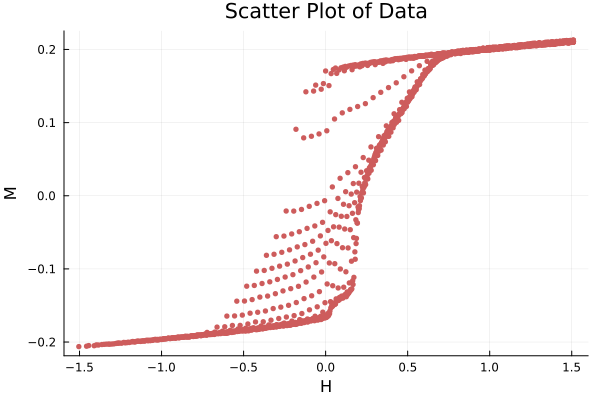

In [5]:
scatter(H_read, M_read,
    title="Scatter Plot of Data",
    xlabel="H",
    ylabel="M",
    legend=false,
    markersize=3,
    markercolor=:indianred,
    markerstrokecolor=:indianred
)

In [6]:
## Detect FORCs (Hr, numPointsPerFORC)
Hr_read = Float64[]
numPointsPerFORC = Int[]

current_Hr = H_read[1]
push!(Hr_read, current_Hr)

counterPointsPerFORC = 1

for i in 2:(length(H_read))
    if H_read[i] < H_read[i-1]
        global current_Hr = H_read[i]
        push!(numPointsPerFORC, counterPointsPerFORC)
        global counterPointsPerFORC = 0
    end
    global counterPointsPerFORC += 1
    push!(Hr_read, current_Hr)
end
push!(numPointsPerFORC, counterPointsPerFORC)
numFORCs = length(numPointsPerFORC)

println("----------- Total $(length(numPointsPerFORC)) FORCs -----------")
println("---------  $(numPointsPerFORC[1]) first / $(numPointsPerFORC[numFORCs]) last ---------")

----------- Total 50 FORCs -----------
---------  3 first / 65 last ---------


In [7]:
## Save Hr-H-M original file
n = length(Hr_read)
if length(H_read) != n || length(M_read) != n
    error("Error: All three arrays must have the same length.")
end

open(cale * "_Hr-H-M_orig.dat", "w") do file
    for i in 1:n
        println(file, "$(Hr_read[i])  $(H_read[i])  $(M_read[i])")
    end
end

In [8]:
function gimmeOneFORC(theFORC::Int64)
    contorNumPoints = 0
    H_interp = Float64[]
    M_interp = Float64[]
    #detect indexes for $(theFORC)
    if theFORC > 1
        for i in 1:theFORC-1
            contorNumPoints += numPointsPerFORC[i]
        end
    else
        contorNumPoints = 0
    end

    #myHr = Hr_read[contorNumPoints]
    startPointOnFORC = contorNumPoints + 1
    push!(H_interp, H_read[startPointOnFORC])
    push!(M_interp, M_read[startPointOnFORC])
    contorNumPoints = 1
    while (Hr_read[startPointOnFORC+contorNumPoints-1] - Hr_read[startPointOnFORC+contorNumPoints]) < 1.0e-5 #eps - compare floats
        push!(H_interp, H_read[startPointOnFORC+contorNumPoints])
        push!(M_interp, M_read[startPointOnFORC+contorNumPoints])
        contorNumPoints += 1
        if (startPointOnFORC + contorNumPoints) > length(Hr_read)
            break
        end
    end
    H_interp, M_interp
end

gimmeOneFORC (generic function with 1 method)

In [10]:
#f = (x, y) -> 0.75 * exp(-((9 * x - 2)^2 + (9 * y - 2)^2) / 4) + 0.75 * exp(-(9 * x + 1)^2 / 49 - (9 * y + 1) / 10) + 0.5 * exp(-((9 * x - 7)^2 + (9 * y - 3)^2) / 4) - 0.2 * exp(-(9 * x - 4)^2 - (9 * y - 7)^2)
#f′ = (x, y) -> [(exp(-(9 * x - 4)^2 - (9 * y - 7)^2) * (162 * x - 72)) / 5 - (3 * exp(-(9 * x - 2)^2 / 4 - (9 * y - 2)^2 / 4) * ((81 * x) / 2 - 9)) / 4 - (exp(-(9 * x - 7)^2 / 4 - (9 * y - 3)^2 / 4) * ((81 * x) / 2 - 63 / 2)) / 2 - (3 * exp(-(9 * y) / 10 - (9 * x + 1)^2 / 49 - 1 / 10) * ((162 * x) / 49 + 18 / 49)) / 4
#    (exp(-(9 * x - 4)^2 - (9 * y - 7)^2) * (162 * y - 126)) / 5 - (3 * exp(-(9 * x - 2)^2 / 4 - (9 * y - 2)^2 / 4) * ((81 * y) / 2 - 9)) / 4 - (exp(-(9 * x - 7)^2 / 4 - (9 * y - 3)^2 / 4) * ((81 * y) / 2 - 27 / 2)) / 2 - (27 * exp(-(9 * y) / 10 - (9 * x + 1)^2 / 49 - 1 / 10)) / 40]
#f′′ = (x, y) -> [(162*exp(-(9 * x - 4)^2 - (9 * y - 7)^2))/5-(243*exp(-(9 * y) / 10 - (9 * x + 1)^2 / 49 - 1 / 10))/98-(243*exp(-(9 * x - 2)^2 / 4 - (9 * y - 2)^2 / 4))/8-(81*exp(-(9 * x - 7)^2 / 4 - (9 * y - 3)^2 / 4))/4+(3*exp(-(9 * y) / 10 - (9 * x + 1)^2 / 49 - 1 / 10)*((162*x)/49+18/49)^2)/4+(3*exp(-(9 * x - 2)^2 / 4 - (9 * y - 2)^2 / 4)*((81*x)/2-9)^2)/4+(exp(-(9 * x - 7)^2 / 4 - (9 * y - 3)^2 / 4)*((81*x)/2-63/2)^2)/2-(exp(-(9 * x - 4)^2 - (9 * y - 7)^2)*(162*x-72)^2)/5 (27*exp(-(9 * y) / 10 - (9 * x + 1)^2 / 49 - 1 / 10)*((162*x)/49+18/49))/40+(3*exp(-(9 * x - 2)^2 / 4 - (9 * y - 2)^2 / 4)*((81*x)/2-9)*((81*y)/2-9))/4+(exp(-(9 * x - 7)^2 / 4 - (9 * y - 3)^2 / 4)*((81*x)/2-63/2)*((81*y)/2-27/2))/2-(exp(-(9 * x - 4)^2 - (9 * y - 7)^2)*(162*x-72)*(162*y-126))/5
#    (27*exp(-(9 * y) / 10 - (9 * x + 1)^2 / 49 - 1 / 10)*((162*x)/49+18/49))/40+(3*exp(-(9 * x - 2)^2 / 4 - (9 * y - 2)^2 / 4)*((81*x)/2-9)*((81*y)/2-9))/4+(exp(-(9 * x - 7)^2 / 4 - (9 * y - 3)^2 / 4)*((81*x)/2-63/2)*((81*y)/2-27/2))/2-(exp(-(9 * x - 4)^2 - (9 * y - 7)^2)*(162*x-72)*(162*y-126))/5 (243*exp(-(9 * y) / 10 - (9 * x + 1)^2 / 49 - 1 / 10))/400+(162*exp(-(9 * x - 4)^2 - (9 * y - 7)^2))/5-(243*exp(-(9 * x - 2)^2 / 4 - (9 * y - 2)^2 / 4))/8-(81*exp(-(9 * x - 7)^2 / 4 - (9 * y - 3)^2 / 4))/4+(3*exp(-(9 * x - 2)^2 / 4 - (9 * y - 2)^2 / 4)*((81*y)/2-9)^2)/4+(exp(-(9 * x - 7)^2 / 4 - (9 * y - 3)^2 / 4)*((81*y)/2-27/2)^2)/2-(exp(-(9 * x - 4)^2 - (9 * y - 7)^2)*(162*y-126)^2)/5]

In [11]:
#x = LinRange(0, 1, 100)
#y = LinRange(0, 1, 100)
#z = [f(x, y) for x in x, y in y]
#∇ = [f′(x, y) for x in x, y in y]
#∇₁ = first.(∇)
#∇₂ = last.(∇)
#H = [f′′(x, y) for x in x, y in y]
#H₁₂ = getindex.(H, 2)
#;

In [12]:
#rng = StableRNG(9199)
#x = rand(rng, 1000)
#y = rand(rng, 1000)
#z = f.(x, y)
#tri = triangulate([x'; y'])
#vorn = voronoi(tri)


In [13]:
tri = triangulate([H_read'; Hr_read'])
vorn = voronoi(tri)

Voronoi Tessellation.
    Number of generators: 1706
    Number of polygon vertices: 3287
    Number of polygons: 1706
    Weighted: false

In [14]:
#points = [x'; y']
#z = f.(x, y)
#tri = triangulate(points)
#∇g = generate_gradients(tri, z)
#;

In [15]:
points = [H_read'; Hr_read']
tri = triangulate(points)
∇g = generate_gradients(tri, M_read)
;

In [16]:
#∇gr, _ = generate_derivatives(tri, z; method=Direct())

In [17]:
#to_mat(H::NTuple{3,Float64}) = [H[1] H[3]; H[3] H[2]]

In [18]:
#_, Hg = generate_derivatives(tri, z)

In [19]:
#_, Hg = generate_derivatives(tri, M_read)
_, Hg = generate_derivatives(tri, M_read, use_cubic_terms=false)
#_, Hg = generate_derivatives(tri, M_read, method=Iterative())

([(0.023221522290942778, -0.013515943233979246), (0.024487396051464435, -0.005552353908835422), (0.029981962287482202, 0.0026539664434992033), (0.0239270299426161, -0.005117230596989433), (0.020977371245244413, -0.0034298716172299036), (0.0143299415603524, -0.0015814651228308353), (0.010798207709051242, 0.0021797012209831875), (0.016919799981374724, 0.001623524760526326), (0.019183121583443676, -0.0006452702241739079), (0.02164295629219973, 0.0018752668216242437)  …  (0.005135850923340609, 0.029517346125127398), (0.017370139617461464, 0.05888720788667112), (0.03333018308667298, 0.03186418701598537), (0.03805447711784043, -0.025116236251600595), (0.022843378027628675, -0.05044719123195156), (0.0018966082450054583, -0.008225022837149255), (0.00401803134576357, 0.05531017934300335), (0.023311985480929935, 0.060794663244375546), (0.030222795543832122, 0.005818731977081297), (0.02101111089238012, -0.03597772021476309)], [(-0.08194446189231351, -0.1844929606337207, 0.0492440415812663), (-0.0

In [20]:
myH = getindex.(Hg, 3)

#heatmap(myH)
;

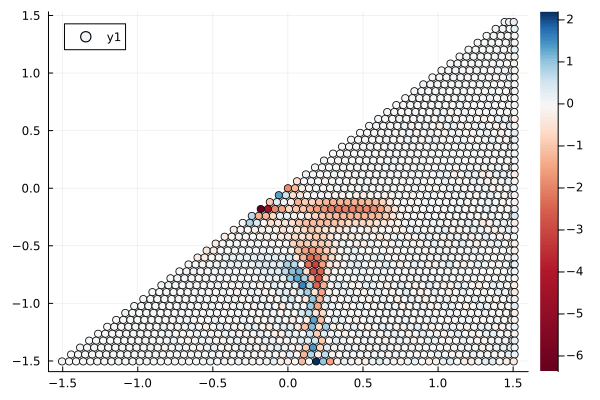

In [29]:
scatter(H_read, Hr_read, marker_z=myH, color=cgrad(:RdBu, scale=log10))

In [22]:
open(cale * "_VoronoiFORC.dat", "w") do file
    for i in 1:n
        println(file, "$(H_read[i])  $(Hr_read[i])  $(-myH[i])")
    end
end